In [1]:
from pathlib import Path
import os
import sys

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

ROOT = Path().resolve().parent
sys.path.append(str(ROOT))

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
def get_spark():
    return SparkSession.builder \
        .appName('TCC - Testes') \
        .getOrCreate()

spark = get_spark()

In [15]:
base_path = "../data/criminalidade/curated/veiculos_setor_parquet"

df = (
    spark.read
    .option("basePath", base_path)
    .option("mergeSchema", "true")
    .parquet(f"{base_path}/ano_trimestre=*")
)

df_ocorrencias = df.withColumn(
    "ano",
    F.regexp_extract(
        F.col("ano_trimestre"),
        r"(\d{4})",
        1
    ).cast("int")
)

df_ocorrencias = (
    df_ocorrencias
    .filter(
        F.col("ano").cast("int").between(2020, 2025)
    )
)

df_ocorrencias = df_ocorrencias.filter(df_ocorrencias.SJ_CD_SETOR.isNotNull())
# df_ocorrencias.printSchema()
df_ocorrencias.show(5, False)

+------------+--------------------+--------------------+--------------+------+-------+------+----------------------+-------------------+------------------------+-------------------+------------------+---------------+----------------------+-------------------+----------------------+------------+--------------+-----------+----------------+-------------+--------------------+------------------+-----------------+-------+-------------------+---------------------------------+-----------------+-----------------+-----------------+------------+------------------------+------------------+--------------------+--------------+----------+-------------+-----------------+---------------+---------------+-------------------+-----------+-----------------+-----------------+----------------------------+----------------------+-------------------+-------------+--------+--------+-----------+---------------+-----------+---------+----------+-----------------+------------+------------+--------+---------+---------

In [16]:
df_censo_final = spark.read.parquet('../data/censo/final/processed/setor')
df_censo = df_censo_final.filter(df_censo_final.nm_mun == 'São Paulo')
# df_censo.printSchema()
df_censo.show(5, False)

+---------------+---------+---------+-----------+-----------+-----------+-------+--------------------+-------+---------+---------+----------+-------------+----------------------------------+--------------------------------+----------------------+--------------------+----------------------+-------------------+--------------------------------------------+------------------+------------------+---------------------+-------------------+-----------+----------+--------------------+-------------------+-------------------+----------------------------+---------------------------------------+-----------------------------------------+-------------------------------------------+------------------------------------+-----------------+-----------------+--------------------------+----------------------------+-------------------------+---------------------------+----------------------------+------------------------+----------------------+-----------------------------+
|cd_setor       |cd_dist  |nm_dist 

In [24]:
from pyspark.sql import functions as F

# ============================================================
# Filtrar roubos e furtos de veículos
# ============================================================

df_crimes_filtrado = (
    df_ocorrencias
    .filter(
        (F.col("is_roubo") == "true") |
        (F.col("is_furto") == "true")
    )
    .filter(F.col("SJ_CD_SETOR").isNotNull())
)

# ============================================================
# Agregar por setor, ano e trimestre
# ============================================================

df_crimes_setor_trimestre = (
    df_crimes_filtrado
    .groupBy(
        F.col("SJ_CD_SETOR").alias("cd_setor"),
        F.col("ano").cast("int").alias("ano"),
        F.col("trimestre_particao").alias("trimestre")
    )
    .agg(
        F.count("*").alias("qt_crimes"),
        F.sum(
            F.when(F.col("is_roubo") == "true", 1).otherwise(0)
        ).alias("qt_roubos"),
        F.sum(
            F.when(F.col("is_furto") == "true", 1).otherwise(0)
        ).alias("qt_furtos")
    )
)

# ============================================================
# Cruzamento com o censo
# ============================================================

df_analise_taxa_crime = (
    df_crimes_setor_trimestre
    .join(
        df_censo,
        on="cd_setor",
        how="inner"
    )
    .filter(F.col("nm_mun") == "São Paulo")
)

# ============================================================
# Taxas
# ============================================================

df_analise_taxa_crime = (
    df_analise_taxa_crime
    .withColumn(
        "tx_crimes_1000_hab",
        F.when(
            F.col("qt_pessoas") > 0,
            (F.col("qt_crimes") / F.col("qt_pessoas")) * 1000
        )
    )
    .withColumn(
        "log_tx_crimes_1000_hab",
        F.log1p(F.col("tx_crimes_1000_hab"))
    )
)

df_analise_correlacao = (
    df_analise_taxa_crime
    .filter(F.col("qt_pessoas") >= 100)
)

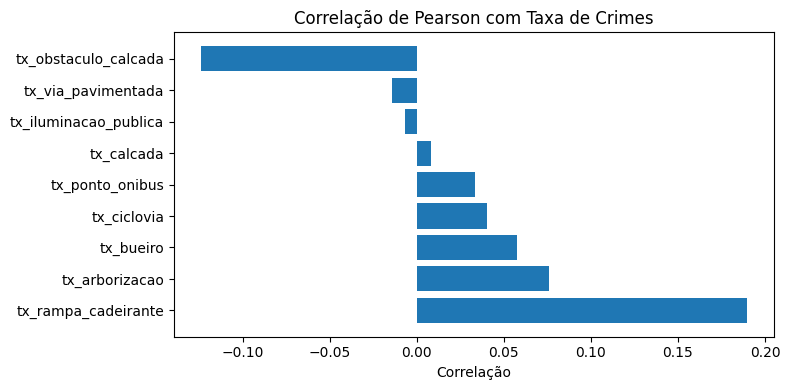

In [26]:
### Variáveis
variaveis_infraestrutura = [
    "tx_via_pavimentada",
    "tx_bueiro",
    "tx_iluminacao_publica",
    "tx_ponto_onibus",
    "tx_ciclovia",
    "tx_calcada",
    "tx_obstaculo_calcada",
    "tx_rampa_cadeirante",
    "tx_arborizacao"
]

resultado = []

for var in variaveis_infraestrutura:

    corr = (
        df_analise_correlacao
        .select(
            F.corr(
                var,
                "tx_crimes_1000_hab"
            ).alias("corr")
        )
        .first()["corr"]
    )

    resultado.append((var, corr))

pdf_corr_pearson = pd.DataFrame(
    resultado,
    columns=[
        "variavel",
        "pearson"
    ]
)

pdf_corr_pearson = pdf_corr_pearson.sort_values(
    "pearson",
    ascending=False
)

pdf_corr_pearson

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.barh(
    pdf_corr_pearson["variavel"],
    pdf_corr_pearson["pearson"]
)

plt.title(
    "Correlação de Pearson com Taxa de Crimes"
)

plt.xlabel("Correlação")

plt.tight_layout()
plt.show()

In [27]:
df_censo.printSchema()

root
 |-- cd_setor: string (nullable = true)
 |-- cd_dist: string (nullable = true)
 |-- nm_dist: string (nullable = true)
 |-- cd_subdist: string (nullable = true)
 |-- ds_situacao: string (nullable = true)
 |-- cd_situacao: string (nullable = true)
 |-- cd_tipo: string (nullable = true)
 |-- categoria_tipo_setor: string (nullable = true)
 |-- cd_mun: string (nullable = true)
 |-- nm_mun: string (nullable = true)
 |-- area_km2: double (nullable = true)
 |-- qt_pessoas: long (nullable = true)
 |-- qt_domicilios: long (nullable = true)
 |-- qt_domicilios_particularesocupados: long (nullable = true)
 |-- qt_domicilios_particulares_vagos: long (nullable = true)
 |-- densidade_populacional: double (nullable = true)
 |-- densidade_domicilios: double (nullable = true)
 |-- tx_domicilios_ocupados: double (nullable = true)
 |-- tx_domicilios_vagos: double (nullable = true)
 |-- avg_moradores_domiciliosparticularesocupados: double (nullable = true)
 |-- tx_via_pavimentada: double (nullable = tr